# 06 - Salinas Hybrid Training

Goal: train the proposed spatial-spectral hybrid model on Salinas and compare it against the CNN baseline using the same split and metrics.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from dfm.data.salinas import (
    SALINAS_CLASS_NAMES,
    SalinasPatchDataset,
    labeled_pixel_indices,
    load_salinas,
    stratified_train_test_split,
)
from dfm.models.hybrid import HybridSpatialSpectralClassifier
from dfm.training.metrics import accuracy_score, macro_f1_score
from dfm.training.profiling import count_parameters

c:\Users\Dines\Documents\Codex\2026-05-15\files-mentioned-by-the-user-dataset0\dense-forest-monitoring\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

data_dir = PROJECT_ROOT / "data" / "raw" / "salinas"
scene = load_salinas(data_dir, download=True)
rows, cols, labels = labeled_pixel_indices(scene.labels)

print("Cube shape (H, W, C):", scene.cube.shape)
print("Label map shape:", scene.labels.shape)
print("Bands:", scene.bands)
print("Classes:", len(scene.class_names))

Cube shape (H, W, C): (512, 217, 204)
Label map shape: (512, 217)
Bands: 204
Classes: 16


In [3]:
train_indices, test_indices = stratified_train_test_split(labels, train_fraction=0.1, seed=SEED)

patch_size = 15
train_dataset = SalinasPatchDataset(scene, indices=train_indices, patch_size=patch_size)
test_dataset = SalinasPatchDataset(scene, indices=test_indices, patch_size=patch_size)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
sample_x, sample_y = train_dataset[0]
print("Sample patch:", sample_x.shape, "label:", sample_y)

Train samples: 5415
Test samples: 48714
Sample patch: (204, 15, 15) label: 8


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridSpatialSpectralClassifier(
    in_channels=scene.bands,
    num_classes=len(SALINAS_CLASS_NAMES),
    feature_dim=128,
    spectral_depth=2,
    spectral_heads=4,
    fusion="gated",
    dropout=0.1,
    max_bands=256,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print("Device:", device)
print("Trainable parameters:", count_parameters(model))

Device: cpu
Trainable parameters: 605712


In [5]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    total = 0
    for x, y in tqdm(loader, leave=False):
        x = x.to(device=device, dtype=torch.float32)
        y = y.to(device=device, dtype=torch.long)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * x.shape[0]
        total += x.shape[0]
    return total_loss / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_true = []
    all_pred = []
    for x, y in tqdm(loader, leave=False):
        x = x.to(device=device, dtype=torch.float32)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_pred.append(pred)
        all_true.append(y.numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": macro_f1_score(y_true, y_pred, num_classes=len(SALINAS_CLASS_NAMES)),
    }

In [6]:
history = []
epochs = 5
best_macro_f1 = -1.0
best_state = None
best_epoch = None

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader)
    metrics = evaluate(model, test_loader)
    row = {"epoch": epoch, "train_loss": train_loss, **metrics}
    history.append(row)

    if metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = metrics["macro_f1"]
        best_epoch = epoch
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(row)

history_df = pd.DataFrame(history)
print(f"Best epoch by macro-F1: {best_epoch} ({best_macro_f1:.4f})")
history_df

{'epoch': 1, 'train_loss': 0.9235000694227351, 'accuracy': 0.8616208892720778, 'macro_f1': 0.8236734129241057}


{'epoch': 2, 'train_loss': 0.28180891567099897, 'accuracy': 0.939216652297081, 'macro_f1': 0.9440267379216514}


{'epoch': 3, 'train_loss': 0.14370830777141635, 'accuracy': 0.9733341544525188, 'macro_f1': 0.9790618858920888}


{'epoch': 4, 'train_loss': 0.13229454919516986, 'accuracy': 0.8613334975571704, 'macro_f1': 0.9107147493621524}


{'epoch': 5, 'train_loss': 0.11986804163136751, 'accuracy': 0.9630906926140329, 'macro_f1': 0.9632335396727585}
Best epoch by macro-F1: 3 (0.9791)


,epoch,train_loss,accuracy,macro_f1
0,1,0.923500,0.861621,0.823673
1,2,0.281809,0.939217,0.944027
2,3,0.143708,0.973334,0.979062
3,4,0.132295,0.861333,0.910715
4,5,0.119868,0.963091,0.963234


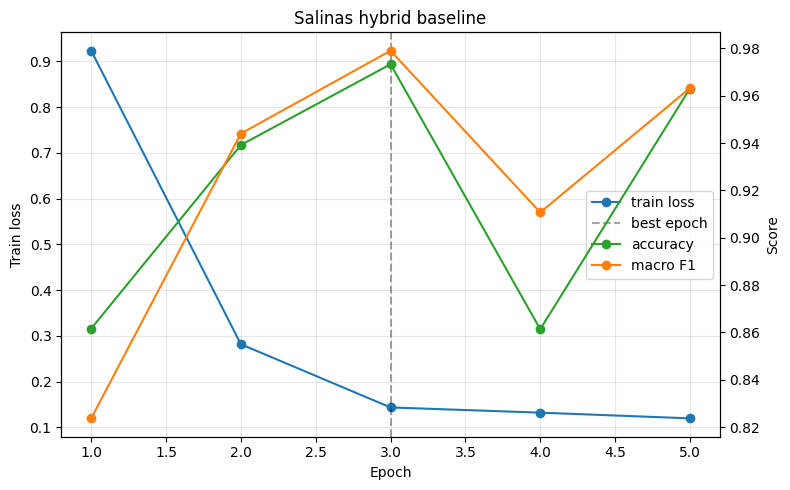

In [7]:
outputs_dir = PROJECT_ROOT / "outputs" / "salinas"
outputs_dir.mkdir(parents=True, exist_ok=True)

history_df.to_csv(outputs_dir / "hybrid_baseline_history.csv", index=False)
if best_state is not None:
    torch.save(
        {
            "model_state_dict": best_state,
            "best_epoch": best_epoch,
            "best_macro_f1": best_macro_f1,
            "class_names": SALINAS_CLASS_NAMES,
            "patch_size": patch_size,
            "bands": scene.bands,
        },
        outputs_dir / "hybrid_baseline_best.pt",
    )

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(history_df["epoch"], history_df["accuracy"], marker="o", color="tab:green", label="accuracy")
ax2.plot(history_df["epoch"], history_df["macro_f1"], marker="o", color="tab:orange", label="macro F1")
if best_epoch is not None:
    ax1.axvline(best_epoch, color="black", linestyle="--", alpha=0.35, label="best epoch")
ax2.set_ylabel("Score")

lines, labels_ = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_ + labels2, loc="center right")
plt.title("Salinas hybrid baseline")
plt.tight_layout()
plt.savefig(outputs_dir / "hybrid_baseline_history.png", dpi=200);

## CNN vs Hybrid Comparison

In [8]:
cnn_path = outputs_dir / "cnn_baseline_history.csv"
comparison_rows = []

if cnn_path.exists():
    cnn_history = pd.read_csv(cnn_path)
    cnn_best = cnn_history.loc[cnn_history["macro_f1"].idxmax()]
    comparison_rows.append({
        "model": "CNN baseline",
        "best_epoch": int(cnn_best["epoch"]),
        "accuracy": float(cnn_best["accuracy"]),
        "macro_f1": float(cnn_best["macro_f1"]),
    })

hybrid_best = history_df.loc[history_df["macro_f1"].idxmax()]
comparison_rows.append({
    "model": "Hybrid spatial-spectral",
    "best_epoch": int(hybrid_best["epoch"]),
    "accuracy": float(hybrid_best["accuracy"]),
    "macro_f1": float(hybrid_best["macro_f1"]),
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(outputs_dir / "cnn_vs_hybrid_comparison.csv", index=False)
comparison_df

,model,best_epoch,accuracy,macro_f1
0,CNN baseline,4,0.948249,0.974376
1,Hybrid spatial-spectral,3,0.973334,0.979062
